# Logistic Regression from Scratch: Who Would Survive the Titanic?

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import chardet 
import numpy as np

OBJECTIVE: 
- **Data preprocessing:**
  Clean the entire dataset first for practice or for storing clean data to be used for readability.
- **Feature Engineer:**
  Make change or drop what we need in order to fit the data into our Logistic Regression model.
- **Model Fitting & Evaluation:**
  logistic regression from scratch, use scitkit learn for measuring and tracking models performance

# Data Collection

In [2]:
#enables to retrieve proper encoding, reads the bytes of the file to identify the encoding. 
with open('d:\\Project Data Sets\\data\\titanic.csv', 'rb') as rawdata: 
    result = chardet.detect(rawdata.read(10000))
print(result)

{'encoding': 'ascii', 'confidence': 1.0, 'language': ''}


In [3]:
df = pd.read_csv('d:\\Project Data Sets\\data\\titanic.csv', encoding= result['encoding'])

# Data Preprocessing

## Basic Data Exploration

We want to explore the basic structure of the data, data types, and meaning. Including a skim of values for mistakes that we can clean in the future such as case sensitivity, duplicates, NULL values, or outliers. 

In [4]:
#shows the first five records, for the last five use .tail() or use .transpose() to transpose the dataset
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
#shows how many (rows, columns)
df.shape

(891, 12)

In [6]:
#shows columns
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [7]:
# shows the object is pandas type dataframe. Shows other column datatypes, rows, and memory usage. 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [8]:
# We can see the correlation matrix, we apply the argument to avoid the string values from names and obtain numerics. 
df.corr(numeric_only=True)

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.035144,0.036847,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.035144,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
Age,0.036847,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.057527,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
Parch,-0.001652,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


<Axes: >

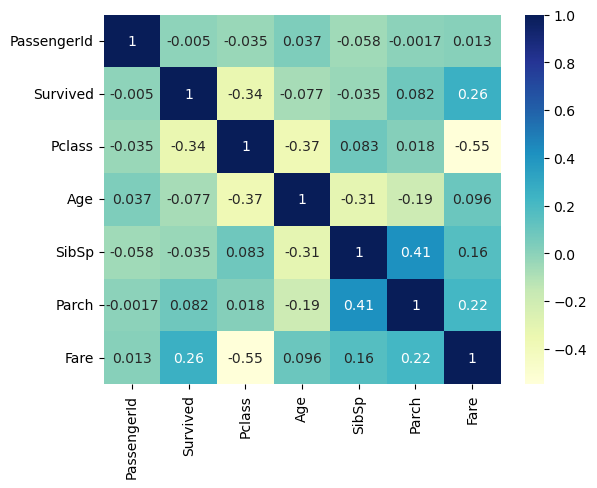

In [9]:
# A better way to visualize the correlation matrix is througha a heatmap similar to a pairplot of correlation, annot= True so we can see the correlation values 
# we set cmap="Yellow, Green, Blue" color mapping 
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap= "YlGnBu")

## Data Cleaning 

### White spaces and Lettering

In [10]:
#Just to be sure we eliminate empty spaces in string objects, using a lambda function. 
def trim_all_columns(df):
    """Trim all columns of whitespace for string values in data frame"""
    trim_strings = [lambda x: x.str.strip() if x.dtype == object else x]
    return df.apply(trim_strings)

In [11]:
#Colum Sex has inconsistent values, it should either be Male, or Female
#or M or F but for readability, we will normalize to "Female" and "Male"

def standardize_sex(df, column="Sex"): 
    """Correct the Sex column values for more consistency, 'Male' & 'Female' 
    to make it more managable for cleaning we lowercase the values in the column first.
    This function tries to fit a general use case rather than to this specfic dataset. """
    df[column] = (
        df[column]
        .str.lower() #applys lowercase
        .apply(lambda x: "Female" if x.startswith("f") or "woman" in x  
                    else "Male" if x.startswith("m") or "guy" in x
                    else "Other")
                 )
    return df[column]

In [12]:
standardize_sex(df,column="Sex")

0        Male
1      Female
2      Female
3      Female
4        Male
        ...  
886      Male
887    Female
888    Female
889      Male
890      Male
Name: Sex, Length: 891, dtype: object

### Duplicate Values

In [13]:
#We can check for duplicate values in passengerId as it seems to be a unique primary key, if it has we can add a fix 

df["PassengerId"].duplicated().any() # returns True for any duplicate rows
df["PassengerId"].duplicated().sum() # returns # of duplicated rows

0

### Null Values

In [14]:
#here we count the nulls in the dataset. We decide what to do for each
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

The null values in 'Cabin' column, there's much we can derive from it so, we don't drop the column.

In [15]:
#Age we can fill in the missing values using the median, as the mean can be affected with outliers.
df["Age"].describe()

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64

In [16]:
#Use .fillna() method w/ the 'inplace =True' to fill in the age onto to the existing series of "Age" 
df["Age"].fillna(df["Age"].median(), inplace =True) 

C:\Users\natha\AppData\Local\Temp\ipykernel_23916\1727386346.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Age"].fillna(df["Age"].median(), inplace =True)


In [17]:
#check to the series for nulls again, which should be 0
df["Age"].isna().sum()

0

In [18]:
#Embarked has 2 NULL values which we will replace with the majority or mode
df["Embarked"].fillna(df["Embarked"].mode, inplace = True)

In [19]:
df["Embarked"].isna().sum()

0

In [20]:
#We check the columns and should see anymore NULLs
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
dtype: int64

Not every columns with NULLs should be drop. Those with cabins probably are rich, meaning they paid more than others. Cabins have different levels and of course those that are in deeper level risk much more during the accident. 

## Feature Engineering & EDA


Before we evolve our data set for the model, we must understand what reasons for choosing the model. We are predicting or assessing the probability of who would survive or not survive the accident based on the predictors, a qualitative binary result. A strong case for logistic regression since we need to use the logistic function to caclulate probability between two qualitative binary responses 0 - 1 (not survive or survive). With this in mind, we can transform and encode the data into numerics and bin some data into something categorical. 

### Sex

In [21]:
#Even though we cleaned the data, now we have to fit the data for the model
#For sex we must change to numerical values 1s and 0s, no need to one hot encode since its binary categories 
df["Sex_Num"] = df["Sex"].apply(lambda x: 1 if x == "Female" else 0)
df["Sex_Num"]

0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    1
889    0
890    0
Name: Sex_Num, Length: 891, dtype: int64

<Axes: xlabel='Sex', ylabel='Survived'>

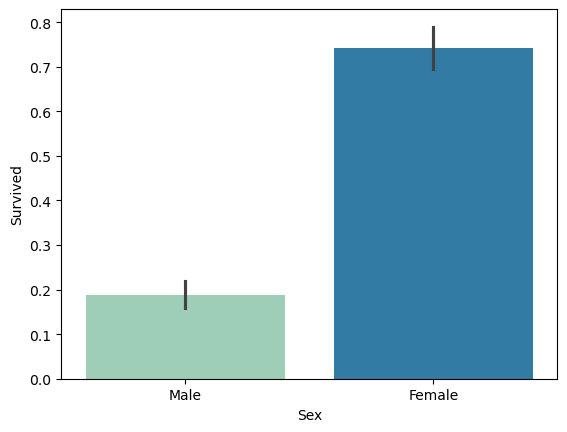

In [22]:
sns.barplot(x='Sex', y='Survived', data=df, hue='Sex', palette= "YlGnBu")

using a barplot, we can see which gender survived comparably. We have females = 1 and males = 0, here we can already see that female have a better chance of survival. 

### Age

In [23]:
# For Age we can bin into certain groups, and rid of labels for the model
df["AgeBin"] = pd.cut(df["Age"], bins =[0,12,18,35,60,100], labels= False)

<Axes: xlabel='AgeBin'>

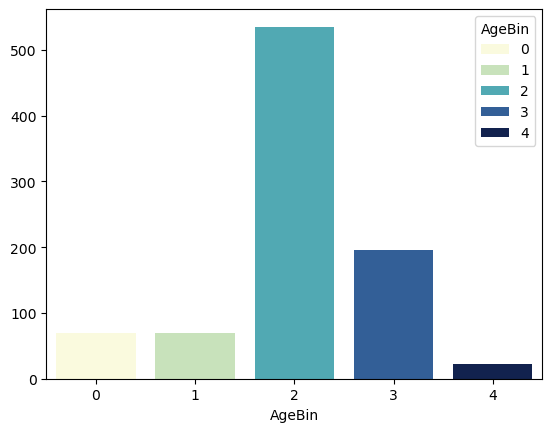

In [24]:
sns.barplot(x=df["AgeBin"].value_counts().index, y= df["AgeBin"].value_counts().values, hue=df["AgeBin"].value_counts().index, palette= "YlGnBu")

From the data it seems that people from ages 18-35 are the majority. 

### Family Size

In [25]:
# For family size we add SibSp and Parch to the indiviual in the row, we add 1 to include the indvivdual
# pd.getdummies for one hot encoding
df["FamilySize"]= df["SibSp"] + df["Parch"] + 1
df["FamilySizeBin"]= pd.cut(df["FamilySize"], bins = [0,1,4,11], labels= ['alone', 'small', 'large'])
FamilySizeBin_df = pd.get_dummies(df["FamilySizeBin"], drop_first = 1) 
FamilySizeBin_df

,small,large
0,True,False
1,True,False
2,False,False
3,True,False
4,False,False
...,...,...
886,False,False
887,False,False
888,True,False
889,False,False


In [26]:
# family size before we bin
df["FamilySize"].value_counts()

FamilySize
1     537
2     161
3     102
4      29
6      22
5      15
7      12
11      7
8       6
Name: count, dtype: int64

### Alone

In [27]:
# We can derive from "FamilySize" those who were by themselves, if "FamilySize" is equal to 1 then that person is alone. if they had family == 0
# From the "FamilySize" to the new alone column, we can see the 1's in "FamilySize" is a 1 in "Alone"
df["Alone"] = df["FamilySize"].apply(lambda x: 1 if x == 1 else 0)
df["Alone"] 

0      0
1      0
2      1
3      0
4      1
      ..
886    1
887    1
888    0
889    1
890    1
Name: Alone, Length: 891, dtype: int64

### Title (Mr, Miss, Mrs, Rare)

In [28]:
# REgex will extract more of the common titles, and we put expand to False so it creates a new series not a dataframe,
# for the rare ones found in the csv, we will just extract them as rare.  
# Extract title from Name column
df["Title"] = df["Name"].str.extract(r',\s*([^\.]*)\.', expand=False)

# Group rare titles together
df["Title"] = df["Title"].replace(
    ['Dr', 'Rev', 'Col', 'Major', 'Capt', 'Lady', 'the Countess', 'Jonkheer', 'Sir', 'Don'],
    'Rare')
df["Title"] = df["Title"].replace({'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'})

# Use .value_counts() to find any outlying titles.
df["Title"].value_counts()

# one hot encode so the model doesn't identify a unwanted pattern (1:miss > 2:mr > 3:mrs > 4:rare) 
# drop miss as it can be inferred to avoid, multicollinearity
title_df = pd.get_dummies(df["Title"], drop_first =True)
title_df

,Mr,Mrs,Rare
0,True,False,False
1,False,True,False
2,False,False,False
3,False,True,False
4,True,False,False
...,...,...,...
886,False,False,True
887,False,False,False
888,False,False,False
889,True,False,False


### Embarked

In [29]:
# We want to map the string values to 1 - 3 to numerical values so the model can measure them, so we one hot encode it.
# To avoid multicollinearity, we have to use the pd.get_dummies instead of map since S,Q,C itself isn't binary and has no apparent order unlike age. 
# pd.get_dummies returns a df that separates and encodes the categories, we can drop "C" column because is it redundant and can be inferred with False False 
df["Embarked"].value_counts()
mapped_embarked_df = pd.get_dummies(df["Embarked"], drop_first =True)
mapped_embarked_df = mapped_embarked_df.drop("C", axis = 1)
mapped_embarked_df

,Q,S
0,False,True
1,False,False
2,False,True
3,False,True
4,False,True
...,...,...
886,False,True
887,False,True
888,False,True
889,False,False


### Cabin

In [30]:
# From value_counts() we see that there are different first letter that might stand for the level of the ships. 
# We can encode the cabin level as a feature. We want null values to count as a string type and we will label them U for "unknown" 
df["Cabin"].value_counts()
df["CabinLevel"] = df["Cabin"].astype(str).str[0]
df["CabinLevel"] = df["CabinLevel"].replace("n" , "U")
cabin_level_df = pd.get_dummies(df["CabinLevel"], drop_first = True)
cabin_level_df

,B,C,D,E,F,G,T,U
0,False,False,False,False,False,False,False,True
1,False,True,False,False,False,False,False,False
2,False,False,False,False,False,False,False,True
3,False,True,False,False,False,False,False,False
4,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,True
887,True,False,False,False,False,False,False,False
888,False,False,False,False,False,False,False,True
889,False,True,False,False,False,False,False,False


### HasCabin 

In [31]:
# We also see not everyone has a cabin so we can assume those who did can afford it and others cant.
# For those without a cabin and with we can encoded 0 those without and 1 those with.
df["HasCabin"] = df["Cabin"].apply(lambda x: 0 if pd.isna(x) else 1)
df["HasCabin"].value_counts()

HasCabin
0    687
1    204
Name: count, dtype: int64

### Fare

For "Fare" since its a continous value with extreme outliers, we should analyze the relationship between the predictor and response. 

The max value is 512 and the mean is 32, which is heavily skewed right. 
It's important to identify these issues because the model will interpret 512 as a outstanding value that determines survivability, more important than other features since its value is high. It's important to view skewness and try to normalize it as much so it doesn't poorly affect the model.

So we must compress the right skewness by logTransform and standardize right after to make sure the model reads the scales correctly and efficiently between different features. 

In [32]:
# high max value
df["Fare"].describe()

count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64

In [33]:
# the number should be close to 0 anything greater than 1 or less than -1 is highly skewed
# anything close to ~0 is symmetric or kinda normal
df["Fare"].skew() 

4.787316519674893

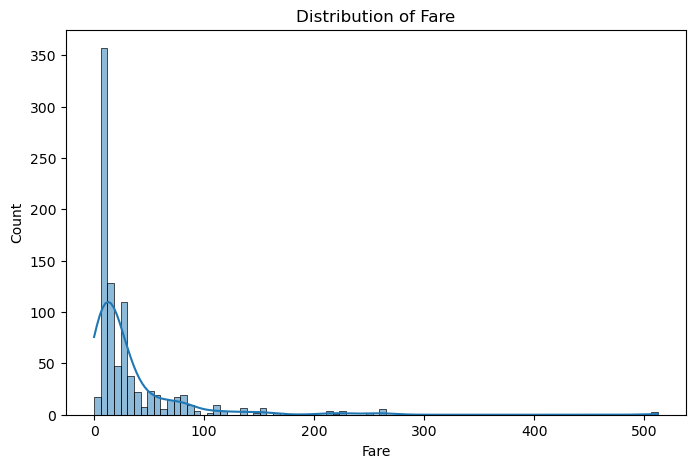

In [34]:
# we can draw a visual as well, a histogram. we also add a list to estimate the model the pdf (probability density function)
plt.figure(figsize=(8,5))
sns.histplot(df['Fare'], bins=85, kde=True)
plt.title('Distribution of Fare')
plt.xlabel('Fare')
plt.ylabel('Count')
plt.show()

In [35]:
# Log transform "Fare" to squish the right skew and distribute the smaller values by a little.
df["LogFare"] = np.log1p(df['Fare'])

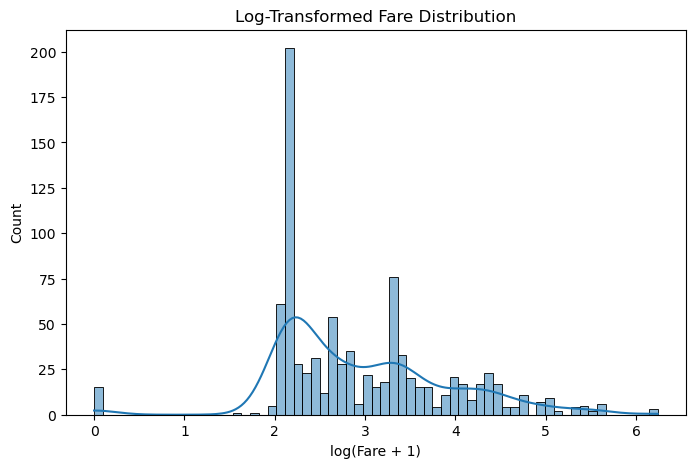

In [36]:
# Here we see the difference with a log transformed "LogFare"
plt.figure(figsize=(8,5))
sns.histplot(df["LogFare"], bins=65, kde=True)
plt.title('Log-Transformed Fare Distribution')
plt.xlabel('log(Fare + 1)')
plt.ylabel('Count')
plt.show()

In [37]:
# Now to finally standardize the feature
def standardize(series):
    """
    Standardize a series with z score normaliztion
    (x - mean) / std
    Return: standardized series with mean = 0 and std = 1
    """
    mean = series.mean()
    std = series.std()
    standardized  = (series - mean) / std
    return standardized
    
df["ScaledFare"] = standardize(df["LogFare"])

#check: mean should be near 0 and std near 1
df["ScaledFare"].mean(), df["ScaledFare"].std()

(-1.7992840039940808e-16, 1.0000000000000018)

In [38]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,...,Sex_Num,AgeBin,FamilySize,FamilySizeBin,Alone,Title,CabinLevel,HasCabin,LogFare,ScaledFare
0,1,0,3,"Braund, Mr. Owen Harris",Male,22.0,1,0,A/5 21171,7.2500,...,0,2,2,small,0,Mr,U,0,2.110213,-0.879247
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",Female,38.0,1,0,PC 17599,71.2833,...,1,3,2,small,0,Mrs,C,1,4.280593,1.360456
2,3,1,3,"Heikkinen, Miss Laina",Female,26.0,0,0,STON/O2. 3101282,7.9250,...,1,2,1,alone,1,NaN,U,0,2.188856,-0.798092
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",Female,35.0,1,0,113803,53.1000,...,1,2,2,small,0,Mrs,C,1,3.990834,1.061442
4,5,0,3,"Allen, Mr. William Henry",Male,35.0,0,0,373450,8.0500,...,0,2,1,alone,1,Mr,U,0,2.202765,-0.783739
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",Male,27.0,0,0,211536,13.0000,...,0,2,1,alone,1,Rare,U,0,2.639057,-0.333511
887,888,1,1,"Graham, Miss Margaret Edith",Female,19.0,0,0,112053,30.0000,...,1,2,1,alone,1,NaN,B,1,3.433987,0.486809
888,889,0,3,"Johnston, Miss Catherine Helen ""Carrie""",Female,28.0,1,2,W./C. 6607,23.4500,...,1,2,4,small,0,NaN,U,0,3.196630,0.241871
889,890,1,1,"Behr, Mr. Karl Howell",Male,26.0,0,0,111369,30.0000,...,0,2,1,alone,1,Mr,C,1,3.433987,0.486809


In [39]:
# create a copy of the df or use the original and drop all redundant columns (to avoid multicollinearity) and keep what we need for the model. 
df_X = df.copy()
df_X = df_X.drop(columns = ["PassengerId", "Pclass", "Name", "Sex", "Ticket", "Age", "Fare", "LogFare", "Cabin", "Embarked","SibSp","Parch","FamilySize","Title","CabinLevel","FamilySizeBin"]) 

In [40]:
# adding the pd.dummies df's to the df.split
df_X = pd.concat([df_X, cabin_level_df, title_df, mapped_embarked_df, FamilySizeBin_df], axis= 1)
df_X

,Survived,Sex_Num,AgeBin,Alone,HasCabin,ScaledFare,B,C,D,E,...,G,T,U,Mr,Mrs,Rare,Q,S,small,large
0,0,0,2,0,0,-0.879247,False,False,False,False,...,False,False,True,True,False,False,False,True,True,False
1,1,1,3,0,1,1.360456,False,True,False,False,...,False,False,False,False,True,False,False,False,True,False
2,1,1,2,1,0,-0.798092,False,False,False,False,...,False,False,True,False,False,False,False,True,False,False
3,1,1,2,0,1,1.061442,False,True,False,False,...,False,False,False,False,True,False,False,True,True,False
4,0,0,2,1,0,-0.783739,False,False,False,False,...,False,False,True,True,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,0,2,1,0,-0.333511,False,False,False,False,...,False,False,True,False,False,True,False,True,False,False
887,1,1,2,1,1,0.486809,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
888,0,1,2,0,0,0.241871,False,False,False,False,...,False,False,True,False,False,False,False,True,True,False
889,1,0,2,1,1,0.486809,False,True,False,False,...,False,False,False,True,False,False,False,False,False,False


# Logistic Regression From Scratch

Start with the Logistic Function / Sigmoid Function which we pass the linear combination to find the probabilities. 

In [41]:
# we use the sigmoid function to pass through the linear combination to obtain probabilities (values 0 - 1).
def sigmoid(z):
    z = np.array(z)
    return 1 / (1 + np.exp(-z))

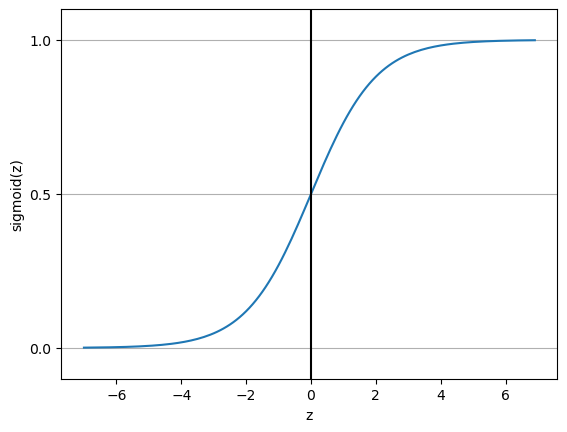

In [42]:
# Logistic Regression Simple Visual Example 
z = np.arange(-7, 7, 0.1) 
phi_z = sigmoid(z)
plt.plot(z, phi_z) 
plt.axvline(0.0, color='k')
plt.ylim(-0.1, 1.1) 
plt.xlabel('z')
plt.ylabel('sigmoid(z)')

#y axis ticks and gridline
plt.yticks([0.0,0.5,1.0])
ax= plt.gca()
ax.yaxis.grid(True)
plt.show()

This is how our model should look like with an S-shaped curve. Our data will return probabilities between 1 & 0 with our decision boundary at .5. Anything above .5 will be classified as 1 and anything below will be classified as 0. 

* 1 = survived, 0 = not survived

In [43]:
# we create a class for logistic Regression 

class LogisticRegression(): 

    # set up alpha/learning rate & number of iterations for gradient descent, we also initialize the weights and bias as none, we'll fill it up later.
    def __init__(self, alpha= 0.001, epochs= 1000):
        self.alpha = alpha
        self.epochs = epochs
        self.weights = None
        self.bias = None
        self.train_loss = []
        self.test_loss = []
        self.train_acc = []
        self.test_acc = []

    # the function use to fit the model, X and y training split as inputs.
    def fit(self, X_training, y_training):
        #initializing variables
        n_samples, n_features = X_training.shape
        self.weights = np.zeros(n_features) 
        self.bias = 0.0
        self.train_loss = []
        self.train_acc = []
        
        for iter in range(self.epochs):
            # Linear Model or combination
            linear_comb = np.dot(X_training, self.weights) + self.bias
            
            # Passing the linear model through simoid function to create probabilities betweeen 0-1
            probabilities = sigmoid(linear_comb) 

            # the partial derivatives of the cost funcitons or the gradients, with respect to weights and bias 
            dw = (1/n_samples) * np.dot(X_training.T, (probabilities - y_training))  
            db = (1/n_samples) * np.sum(probabilities - y_training)

            # update gradient for weights and bias simulataneously
            self.weights -= self.alpha * dw
            self.bias -= self.alpha * db

            #Log loss / Binary Cross Entropy function - use as good way to track loss 
            loss = -(1/n_samples) * np.sum(y_training * np.log(probabilities + 1e-9) + (1- y_training) * np.log(1 - probabilities + 1e-9))
            self.train_loss.append(loss)

            #track accuracy 
            preds = np.mean(probabilities >= 0.5).astype(int) 
            acc = np.mean(preds == y_training)
            self.train_acc.append(acc)

    def evaluate_fit(self, X_train, y_train, X_test, y_test, threshold=0.05):
        

        n_train_samples = len(y_train)
        n_test_samples = len(y_test)
    
        # Predicted probabilities
        train_probs = sigmoid(np.dot(X_train, self.weights) + self.bias)
        test_probs = sigmoid(np.dot(X_test, self.weights) + self.bias)
    
        # Log loss
        train_loss = -(1 / n_train_samples) * np.sum(
            y_train * np.log(train_probs + 1e-9) +
            (1 - y_train) * np.log(1 - train_probs + 1e-9)
        )
    
        test_loss = -(1 / n_test_samples) * np.sum(
            y_test * np.log(test_probs + 1e-9) +
            (1 - y_test) * np.log(1 - test_probs + 1e-9)
        )
    
        # Predictions
        train_preds = (train_probs >= 0.5).astype(int)
        test_preds = (test_probs >= 0.5).astype(int)
    
        train_acc = np.mean(train_preds == y_train)
        test_acc = np.mean(test_preds == y_test)
    
        print(f"Train loss: {train_loss:.4f} | Test loss: {test_loss:.4f}")
        print(f"Train acc: {train_acc:.4f} | Test acc: {test_acc:.4f}")
    
        # Diagnosis
        loss_gap = abs(train_loss - test_loss)
        acc_gap = abs(train_acc - test_acc)
    
        if train_acc < 0.7 and test_acc < 0.7:
            diagnosis = "Underfitting"
        elif acc_gap > threshold and train_loss < test_loss:
            diagnosis = "Overfitting"
        elif loss_gap < threshold and acc_gap < threshold:
            diagnosis = "Good Fit"
        else:
            diagnosis = "Borderline Fit"
    
        print(f"\nDiagnosis: {diagnosis}")
        
    # use to predict the test data set. 
    def predict(self, X_test, threshold= 0.5): 
        linear_pred = np.dot(X_test, self.weights) + self.bias
        y_pred = sigmoid(linear_pred) 
        classification = [0 if y<=threshold else 1 for y in y_pred] 
        return classification

    def predict_probs(self, X):
        linear = np.dot(X, self.weights) + self.bias
        return sigmoid(linear)

# Stratify & Split Training and Test Set + Kfold Cross Validation Using Scikit Learn

 * changes made:
 * from using the hold out validation method to kfold cross validation method

In [44]:
# Stratifying train and tests splits
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold
)
# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

In [45]:
# Stratified split
X, y = df_X.iloc[:, 1:].values, df_X.iloc[:, 0].values 
X_train, X_test, y_train, y_test =\
    train_test_split(X, y, 
                     test_size= 0.3,
                     random_state= 115, 
                     stratify= y) 

In [46]:
X_train = np.array(X_train, np.float64)
X_test = np.array(X_test, np.float64) 
y_train = np.array(y_train, np.float64) 
y_test = np.array(y_test, np.float64)

## Cross-Validation Results
The logistic regression model achieved a mean cross-validation accuracy of
**0.81 ± 0.07**. This indicates stable generalization performance across folds,
with expected variability given the limited dataset size.

The small standard error suggest that the model captures meaningful survival patterns while
avoiding significant overfitting.

In [47]:
# K-fold crossing from scikit learn
kfold = StratifiedKFold(n_splits=20, shuffle=True, random_state=115).split(X_train, y_train)

fold_scores = []
all_train_accs = []
all_train_losses = []

for fold, (train_indx, val_indx) in enumerate(kfold): 
    
    model_cv = LogisticRegression(alpha= 0.01, epochs= 3000) 
    model_cv.fit(X_train[train_indx], y_train[train_indx])

    val_pred = model_cv.predict(X_train[val_indx]) 
    val_acc = accuracy_score(y_train[val_indx], val_pred) 
    fold_scores.append(val_acc)
    
    # Store this fold's learning curves
    all_train_losses.append(model_cv.train_loss)
    all_train_accs.append(model_cv.train_acc)
    
    print(f"Fold {fold+1} Accuracy: {val_acc:.4f}")

print(f"\nMean CV Accuracy: {np.mean(fold_scores):.4f} +- {np.std(fold_scores):.4f}")

Fold 1 Accuracy: 0.9375
Fold 2 Accuracy: 0.7812
Fold 3 Accuracy: 0.8438
Fold 4 Accuracy: 0.8710
Fold 5 Accuracy: 0.7742
Fold 6 Accuracy: 0.8710
Fold 7 Accuracy: 0.6774
Fold 8 Accuracy: 0.6452
Fold 9 Accuracy: 0.7742
Fold 10 Accuracy: 0.8065
Fold 11 Accuracy: 0.7742
Fold 12 Accuracy: 0.7742
Fold 13 Accuracy: 0.8065
Fold 14 Accuracy: 0.8387
Fold 15 Accuracy: 0.8065
Fold 16 Accuracy: 0.8710
Fold 17 Accuracy: 0.8065
Fold 18 Accuracy: 0.8710
Fold 19 Accuracy: 0.8065
Fold 20 Accuracy: 0.8710

Mean CV Accuracy: 0.8104 +- 0.0662


### Cross-Validation Performance

The model was evaluated using 20-fold cross-validation. Accuracy across folds
ranged from approximately 0.65 to 0.94, reflecting expected variability due to
the small dataset size and sampling differences across folds.  
The mean cross-validation accuracy was **0.81 ± 0.07**, indicating stable
generalization performance. Suggesting that the model is not overfitting and
captures meaningful patterns in the data.

# Model Fit, Evaluation and Hyperparameter Tuning

In [48]:
mean_train_loss = np.mean(all_train_losses, axis=0)
std_train_loss = np.std(all_train_losses, axis=0)
mean_train_acc = np.mean(all_train_accs, axis=0)
std_train_acc = np.std(all_train_accs, axis=0)

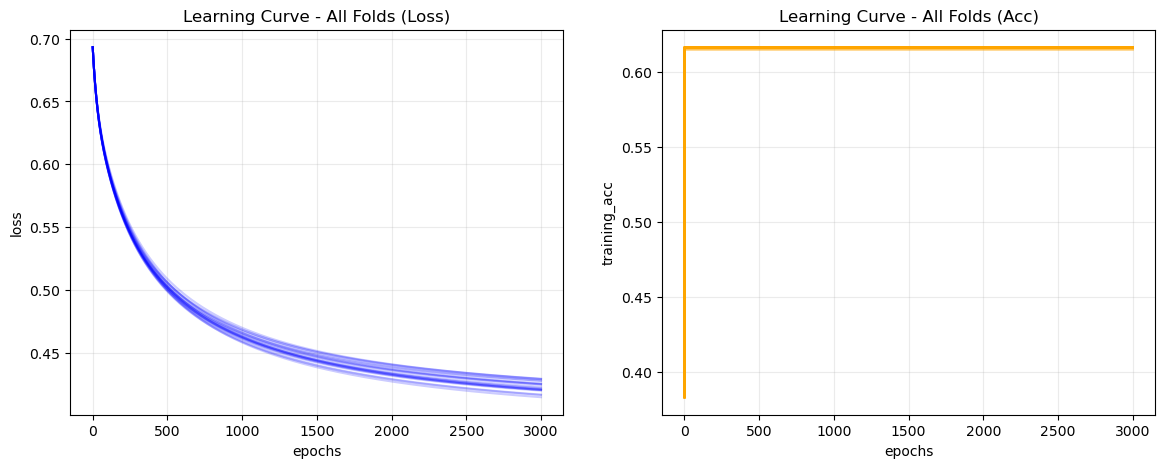

In [49]:
# plotting the learning curve loss and acc from the kfold cross. 
epochs= range(1, len(mean_train_loss)+1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for iteration, loss in enumerate(all_train_losses): 
    ax1.plot(epochs, loss, label=f"Fold{fold+1}", color='blue', alpha= 0.2)
ax1.set_xlabel('epochs')
ax1.set_ylabel('loss')
ax1.grid(True, alpha=.25)
ax1.set_title('Learning Curve - All Folds (Loss)')

for acc_iter, acc in enumerate(all_train_accs): 
    ax2.plot(epochs, acc, label=f'Fold{acc_iter+1}', color= 'orange', alpha= 0.5) 
ax2.set_xlabel('epochs')
ax2.set_ylabel('training_acc')
ax2.grid(True, alpha=.25)
ax2.set_title('Learning Curve - All Folds (Acc)')

plt.show()

## Kfold Cross Validation
The learning curve averages all folds.  
**Mean CV Accuracy: 0.8104 +- 0.0662** is great metric for us.  
The training accuracy might seem some what wrong but it essentially learns the descision boundary very quickly with less epochs then flattens out, which is very good for our model. 

In [64]:
# Getting predictions 0 - 1
y_pred = model_cv.predict(X_test) # classification 0 / 1 
y_pred_prob = model_cv.predict_probs(X_test) # probabilities

# we can do the same for training set to check for overfitting
y_train_pred = model_cv.predict(X_train)
y_train_prob = model_cv.predict_probs(X_train)

In [65]:
# accuracy 
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_pred)

# calculate roc-auc 
train_auc = roc_auc_score(y_train, y_train_prob)
test_auc = roc_auc_score(y_test, y_pred_prob)
fpr_train, tpr_train, _ = roc_curve(y_train, y_train_prob) 
fpr_test, tpr_test, _ = roc_curve(y_test, y_pred_prob) 

In [66]:
# metrics
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred) 
f1 = f1_score(y_test, y_pred) 
cm = confusion_matrix(y_test, y_pred)
cr = classification_report(y_test, y_pred) 
roc_auc = roc_auc_score(y_test, y_pred)

print("Accuracy:")
print(f" Training: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f" Test: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f" Difference: {abs(train_accuracy - test_accuracy):.4f}%\n")

print(f"Precision: {precision:.4f}\n")  
print(f"Recall: {recall:.4f}\n") 
print(f"F1: {f1:.4f}\n") 

print(f"Confusion Matrix:")
print(f"{cm}\n")
print(f"Classification Report:")
print(f"{cr}\n") 

print(f"Training AUC: {train_auc:.4f}") 
print(f"Test AUC: {test_auc:.4f}")
print(f"Difference: {abs(train_auc - test_auc):.4f}")

Accuracy:
 Training: 0.8090 (80.90%)
 Test: 0.7724 (77.24%)
 Difference: 0.0366%

Precision: 0.6944

Recall: 0.7282

F1: 0.7109

Confusion Matrix:
[[132  33]
 [ 28  75]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.82      0.80      0.81       165
         1.0       0.69      0.73      0.71       103

    accuracy                           0.77       268
   macro avg       0.76      0.76      0.76       268
weighted avg       0.77      0.77      0.77       268


Training AUC: 0.8735
Test AUC: 0.8487
Difference: 0.0248


### Model Performance Summary

The logistic regression model achieved a training accuracy of 81.5% and a test
accuracy of 77.6%, resulting in a modest generalization gap of approximately 4%.
This suggests that the model generalizes well without significant overfitting.

For the survival class, the model achieved a precision of 0.70, recall of 0.74,
and an F1-score of 0.72, indicating a balanced trade-off between false positives
and false negatives. Performance was further supported by a confusion matrix
showing well-distributed prediction errors.
|
The model achieved a test AUC of 0.85, demonstrating strong class separation and
robust performance on unseen data.

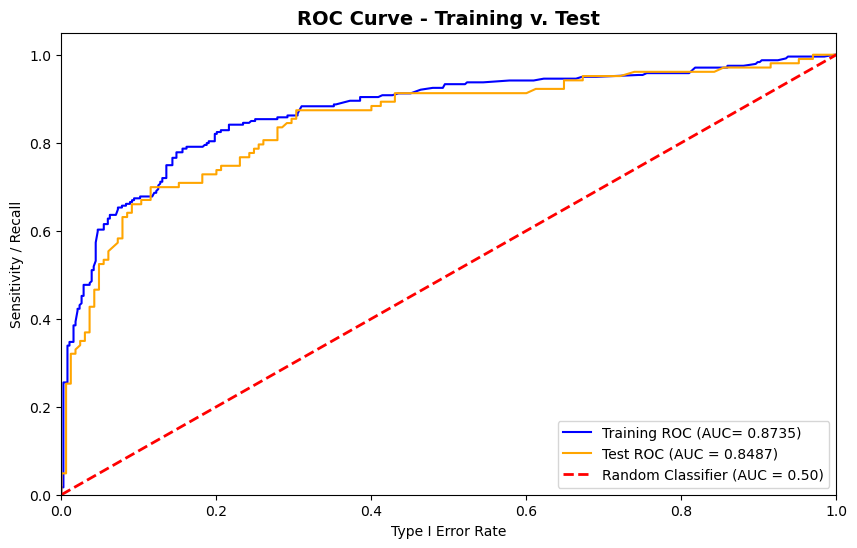

In [58]:
# roc_curve
fig, ax = plt.subplots(1,1, figsize=(10,6)) 
ax.plot(fpr_train, tpr_train, color='blue', label= f'Training ROC (AUC= {train_auc:.4f})')
ax.plot(fpr_test, tpr_test, color='orange', label=f'Test ROC (AUC = {test_auc:.4f})')
ax.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Random Classifier (AUC = 0.50)')

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])

ax.set_xlabel('Type I Error Rate') 
ax.set_ylabel('Sensitivity / Recall') 
ax.set_title('ROC Curve - Training v. Test', fontsize=14, fontweight='bold')
ax.legend(loc= 'lower right')

### AUC and ROC Interpretation

Visually, we want the curve to remain on top of the red dashed line, as it represents "random guessing". 

Training AUC: 0.8735  
Test AUC: 0.8487  
Difference: 0.0248

AUC is a strong primary evaluation metric because it measures the model’s
ability to rank positive instances higher than negative ones, independent of
any specific classification threshold.

The model achieved a test AUC of 0.85, indicating strong discriminatory power.
The close alignment between training and test AUC values suggests good
generalization and minimal overfitting.